In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

In [2]:
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)


In [4]:
df = pd.read_csv("../data/ecommerce_sales_data.csv")

In [5]:
df.head()

,order_id,year,month,quarter,is_weekend_order,platform,country,customer_segment,customer_age_group,customer_gender,acquisition_channel,device_used,product_category,unit_price_usd,quantity_ordered,order_value_usd,discount_pct,discount_amount_usd,final_amount_usd,shipping_cost_usd,tax_amount_usd,total_paid_usd,payment_method,shipping_method,delivery_days,product_rating,review_submitted,returned,return_reason,customer_satisfaction,session_duration_minutes,pages_viewed,cart_abandoned_before,wishlist_used,coupon_used,subscription_member,repeat_purchase_count,loyalty_points
0,ORD0000001,2022,4,Q2,Yes,AliExpress,Germany,New Customer,35-44,Male,Influencer,Mobile,Home & Kitchen,269.67,2,539.34,20,107.87,431.47,2.23,22.69,456.39,Debit Card,Standard,9,5,No,No,NaN,Dissatisfied,78.7,2,Yes,No,No,No,0,0
1,ORD0000002,2023,6,Q2,Yes,Flipkart,Australia,Loyal Customer,35-44,Male,Direct,Mobile,Beauty & Personal Care,150.00,1,150.00,25,37.50,112.50,14.35,22.17,149.02,PayPal,Express,3,4,No,No,NaN,Neutral,18.2,7,No,Yes,No,No,9,198
2,ORD0000003,2022,2,Q1,Yes,Amazon,Turkey,VIP Customer,45-54,Male,Organic Search,Mobile,Electronics,2000.00,3,6000.00,15,900.00,5100.00,0.00,683.94,5783.94,Cash on Delivery,Free Shipping,7,4,Yes,No,NaN,Very Dissatisfied,5.1,1,No,No,No,Yes,30,1020
3,ORD0000004,2022,7,Q3,No,AliExpress,USA,New Customer,35-44,Male,Paid Ads,Desktop,Health & Wellness,214.85,1,214.85,5,10.74,204.11,0.00,17.83,221.94,Bank Transfer,Free Shipping,7,4,Yes,No,NaN,Satisfied,22.0,6,Yes,No,No,Yes,0,0
4,ORD0000005,2024,4,Q2,No,Daraz,Australia,Loyal Customer,35-44,Female,Social Media,Mobile,Automotive,400.47,1,400.47,30,120.14,280.33,15.33,49.05,344.71,Cash on Delivery,Express,3,5,No,No,NaN,Satisfied,4.5,8,Yes,No,Yes,No,13,598


In [6]:
df.columns.to_list()

['order_id',
 'year',
 'month',
 'quarter',
 'is_weekend_order',
 'platform',
 'country',
 'customer_segment',
 'customer_age_group',
 'customer_gender',
 'acquisition_channel',
 'device_used',
 'product_category',
 'unit_price_usd',
 'quantity_ordered',
 'order_value_usd',
 'discount_pct',
 'discount_amount_usd',
 'final_amount_usd',
 'shipping_cost_usd',
 'tax_amount_usd',
 'total_paid_usd',
 'payment_method',
 'shipping_method',
 'delivery_days',
 'product_rating',
 'review_submitted',
 'returned',
 'return_reason',
 'customer_satisfaction',
 'session_duration_minutes',
 'pages_viewed',
 'cart_abandoned_before',
 'wishlist_used',
 'coupon_used',
 'subscription_member',
 'repeat_purchase_count',
 'loyalty_points']

In [8]:
df.dtypes

order_id                        str
year                          int64
month                         int64
quarter                         str
is_weekend_order                str
platform                        str
country                         str
customer_segment                str
customer_age_group              str
customer_gender                 str
acquisition_channel             str
device_used                     str
product_category                str
unit_price_usd              float64
quantity_ordered              int64
order_value_usd             float64
discount_pct                  int64
discount_amount_usd         float64
final_amount_usd            float64
shipping_cost_usd           float64
tax_amount_usd              float64
total_paid_usd              float64
payment_method                  str
shipping_method                 str
delivery_days                 int64
product_rating                int64
review_submitted                str
returned                    

In [9]:
null_counts = df.isnull().sum()
print("Null values per column:")
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "Zero null values!")

Null values per column:
return_reason    9359
dtype: int64


In [10]:
df.describe()

,year,month,unit_price_usd,quantity_ordered,order_value_usd,discount_pct,discount_amount_usd,final_amount_usd,shipping_cost_usd,tax_amount_usd,total_paid_usd,delivery_days,product_rating,session_duration_minutes,pages_viewed,repeat_purchase_count,loyalty_points
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2022.678000,6.501700,381.007858,1.760000,667.607804,13.523000,89.751641,577.856163,7.834561,71.943259,657.633983,4.300200,3.980700,33.434420,5.520200,6.818600,203.043700
std,1.067253,3.454242,440.115690,1.032912,962.168338,12.066608,194.408407,845.546522,9.070157,112.916478,950.589301,2.314955,1.003508,29.367996,2.307883,10.809384,353.008132
min,2021.000000,1.000000,8.540000,1.000000,12.430000,0.000000,0.000000,6.930000,0.000000,0.710000,8.070000,1.000000,1.000000,1.300000,1.000000,0.000000,0.000000
25%,2022.000000,3.000000,94.775000,1.000000,134.477500,0.000000,0.000000,112.680000,0.000000,13.020000,135.370000,2.000000,4.000000,14.300000,4.000000,0.000000,0.000000
50%,2023.000000,7.000000,193.765000,1.000000,300.000000,10.000000,25.505000,259.350000,4.650000,30.785000,300.210000,4.000000,4.000000,24.550000,5.000000,2.000000,64.000000
75%,2024.000000,9.000000,497.585000,2.000000,800.000000,20.000000,89.050000,688.377500,12.002500,81.265000,784.290000,6.000000,5.000000,42.200000,7.000000,9.000000,220.000000
max,2024.000000,12.000000,2000.000000,5.000000,10000.000000,50.000000,4000.000000,10000.000000,39.990000,1829.020000,11829.020000,9.000000,5.000000,180.000000,16.000000,49.000000,2352.000000


In [12]:
return_counts = df["returned"].value_counts()
print(return_counts)
print(f"\nReturn Rate: {return_counts['Yes'] / len(df) * 100:.1f}%")

returned
No     9359
Yes     641
Name: count, dtype: int64

Return Rate: 6.4%


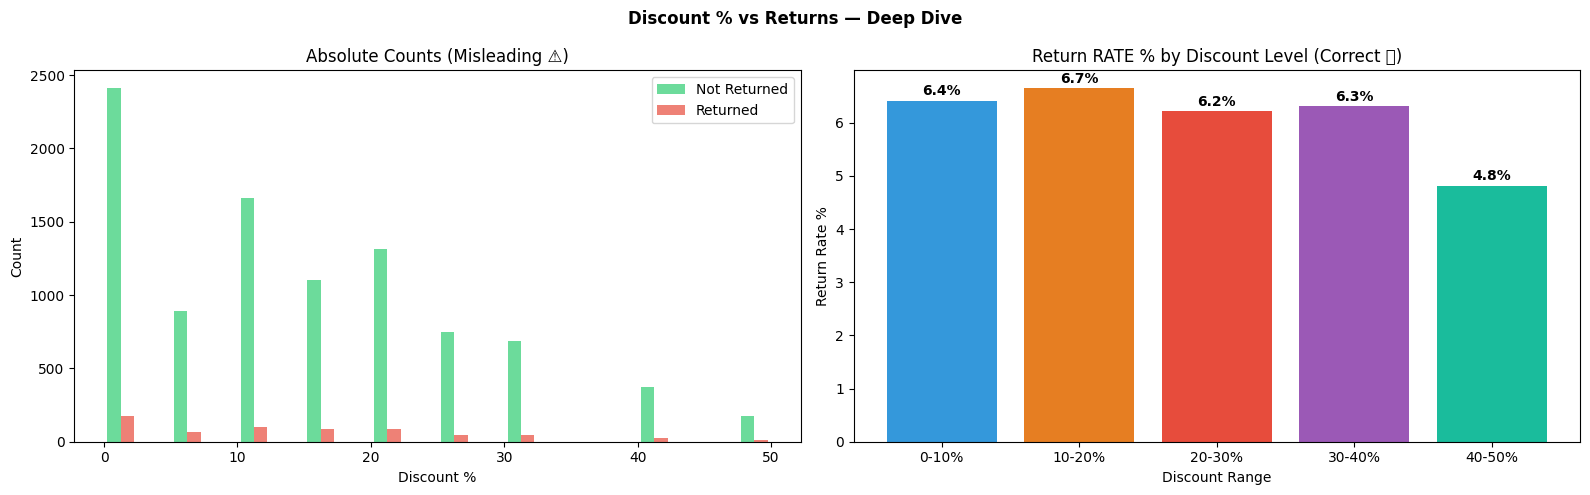


📊 Return Rate by Discount Level:
discount_bin  returned
       0-10%  6.411465
      10-20%  6.651199
      20-30%  6.217277
      30-40%  6.313131
      40-50%  4.812834


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Discount % vs Returns — Deep Dive", fontweight="bold")

# Left chart — Absolute counts (what you saw)
returned_yes = df[df["returned"] == "Yes"]["discount_pct"]
returned_no  = df[df["returned"] == "No"]["discount_pct"]

axes[0].hist([returned_no, returned_yes],
             bins=20,
             label=["Not Returned", "Returned"],
             color=["#2ecc71", "#e74c3c"],
             alpha=0.7)
axes[0].set_title("Absolute Counts (Misleading ⚠️)")
axes[0].set_xlabel("Discount %")
axes[0].set_ylabel("Count")
axes[0].legend()

# Right chart — Return RATE per discount level (correct way)
df["discount_bin"] = pd.cut(df["discount_pct"], 
                             bins=[0, 10, 20, 30, 40, 50],
                             labels=["0-10%", "10-20%", "20-30%", "30-40%", "40-50%"],
                             include_lowest=True)

return_rate_by_discount = df.groupby("discount_bin")["returned"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).reset_index()

axes[1].bar(return_rate_by_discount["discount_bin"].astype(str),
            return_rate_by_discount["returned"],
            color=["#3498db", "#e67e22", "#e74c3c", "#9b59b6", "#1abc9c"])
axes[1].set_title("Return RATE % by Discount Level (Correct ✅)")
axes[1].set_xlabel("Discount Range")
axes[1].set_ylabel("Return Rate %")

for i, v in enumerate(return_rate_by_discount["returned"]):
    axes[1].text(i, v + 0.1, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print("\n📊 Return Rate by Discount Level:")
print(return_rate_by_discount.to_string(index=False))

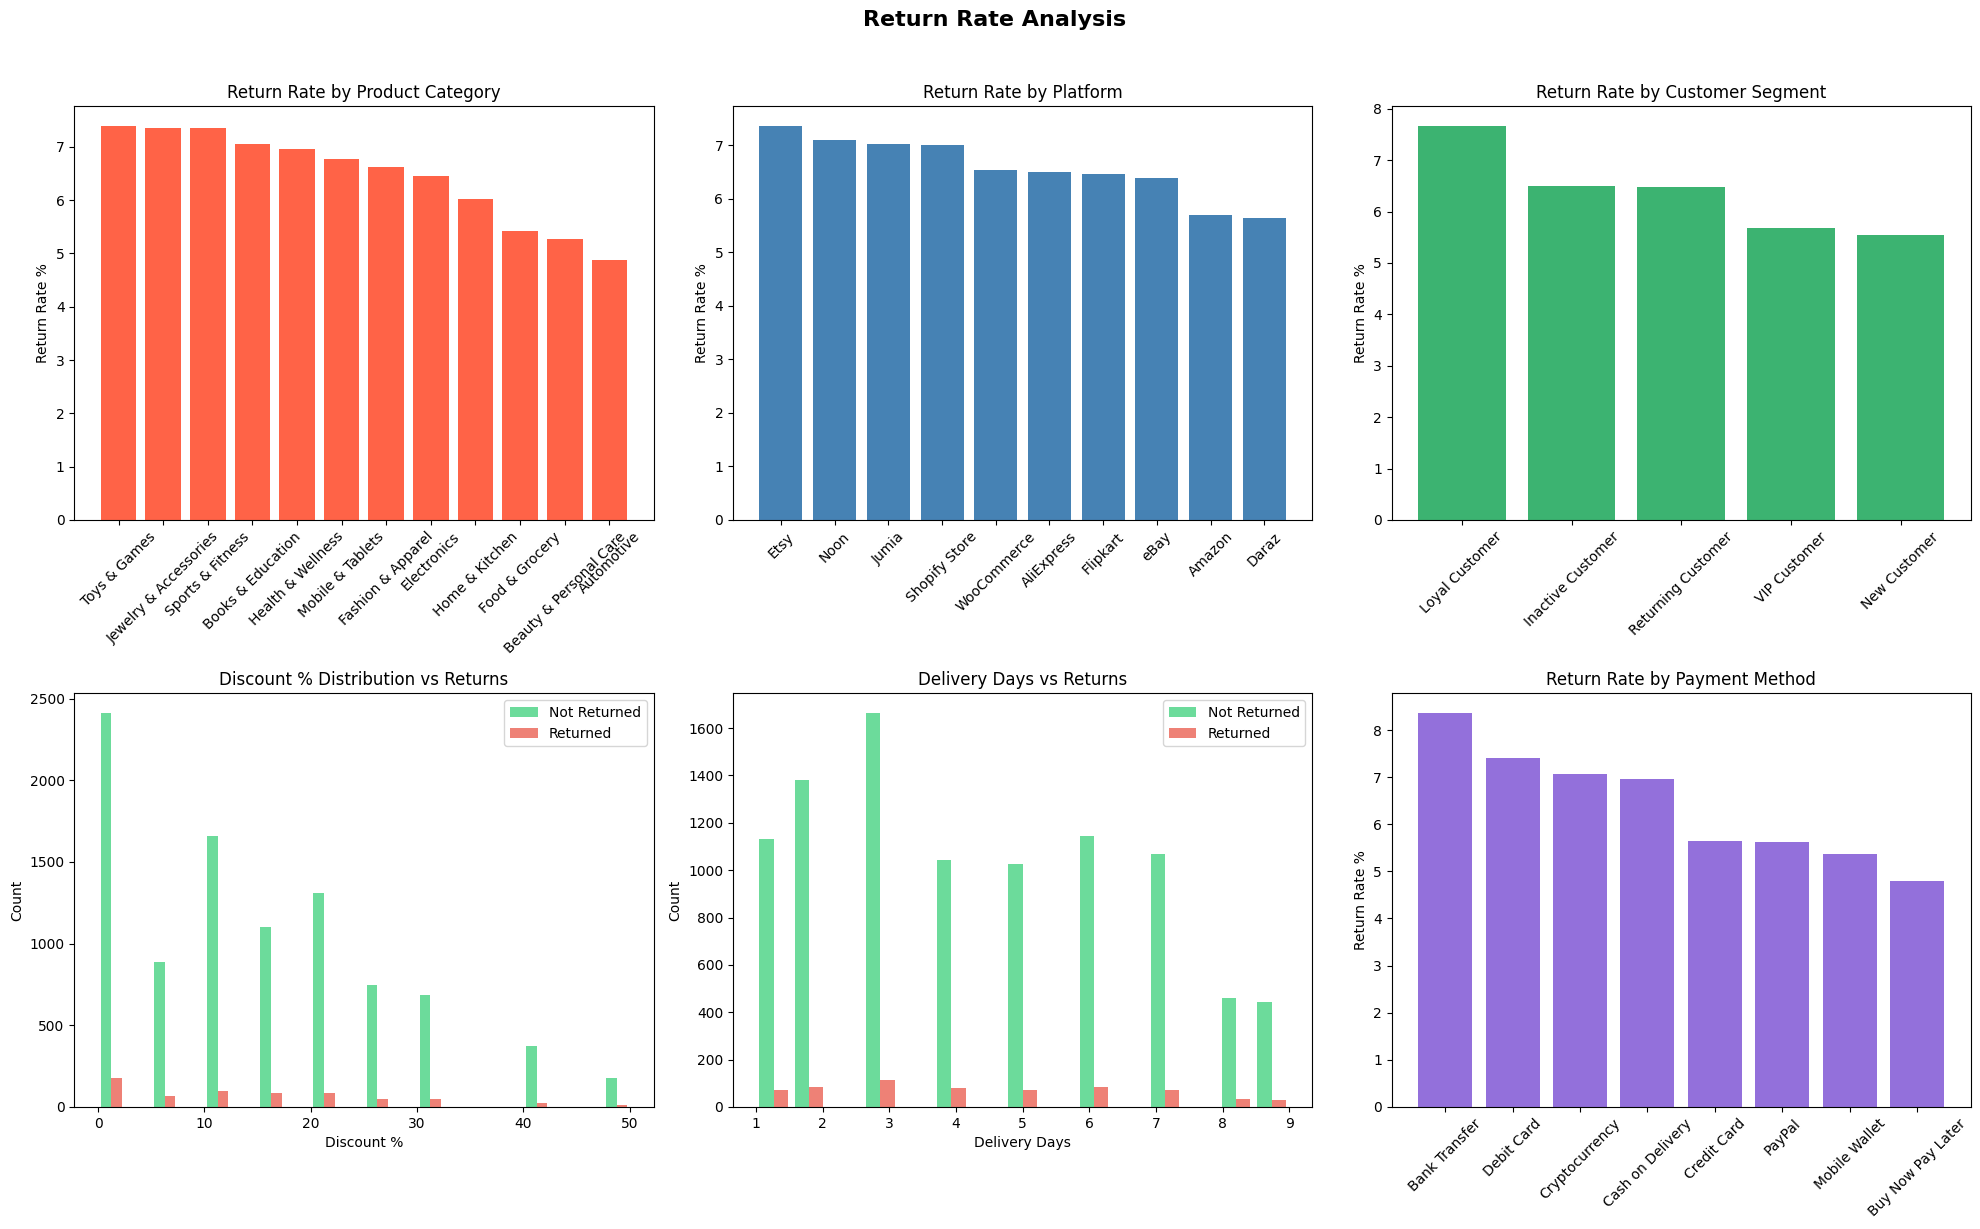

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Return Rate Analysis", fontsize=16, fontweight="bold", y=1.02)

# 1. Return Rate by Product Category
category_returns = df.groupby("product_category")["returned"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).sort_values(ascending=False)

axes[0,0].bar(category_returns.index, category_returns.values, color="tomato")
axes[0,0].set_title("Return Rate by Product Category")
axes[0,0].set_ylabel("Return Rate %")
axes[0,0].tick_params(axis="x", rotation=45)

# 2. Return Rate by Platform
platform_returns = df.groupby("platform")["returned"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).sort_values(ascending=False)

axes[0,1].bar(platform_returns.index, platform_returns.values, color="steelblue")
axes[0,1].set_title("Return Rate by Platform")
axes[0,1].set_ylabel("Return Rate %")
axes[0,1].tick_params(axis="x", rotation=45)

# 3. Return Rate by Customer Segment
segment_returns = df.groupby("customer_segment")["returned"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).sort_values(ascending=False)

axes[0,2].bar(segment_returns.index, segment_returns.values, color="mediumseagreen")
axes[0,2].set_title("Return Rate by Customer Segment")
axes[0,2].set_ylabel("Return Rate %")
axes[0,2].tick_params(axis="x", rotation=45)

# 4. Discount % vs Returns
# Why: High discounts may trigger impulse buys → more returns
returned_yes = df[df["returned"] == "Yes"]["discount_pct"]
returned_no  = df[df["returned"] == "No"]["discount_pct"]

axes[1,0].hist([returned_no, returned_yes], 
               bins=20, 
               label=["Not Returned", "Returned"],
               color=["#2ecc71", "#e74c3c"], 
               alpha=0.7)
axes[1,0].set_title("Discount % Distribution vs Returns")
axes[1,0].set_xlabel("Discount %")
axes[1,0].set_ylabel("Count")
axes[1,0].legend()

# 5. Delivery Days vs Returns
# Why: Late delivery frustrates customers → they return products
axes[1,1].hist([df[df["returned"]=="No"]["delivery_days"],
                df[df["returned"]=="Yes"]["delivery_days"]],
               bins=15,
               label=["Not Returned", "Returned"],
               color=["#2ecc71", "#e74c3c"],
               alpha=0.7)
axes[1,1].set_title("Delivery Days vs Returns")
axes[1,1].set_xlabel("Delivery Days")
axes[1,1].set_ylabel("Count")
axes[1,1].legend()

# 6. Return Rate by Payment Method
# Why: COD orders tend to have higher return rates
payment_returns = df.groupby("payment_method")["returned"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).sort_values(ascending=False)

axes[1,2].bar(payment_returns.index, payment_returns.values, color="mediumpurple")
axes[1,2].set_title("Return Rate by Payment Method")
axes[1,2].set_ylabel("Return Rate %")
axes[1,2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

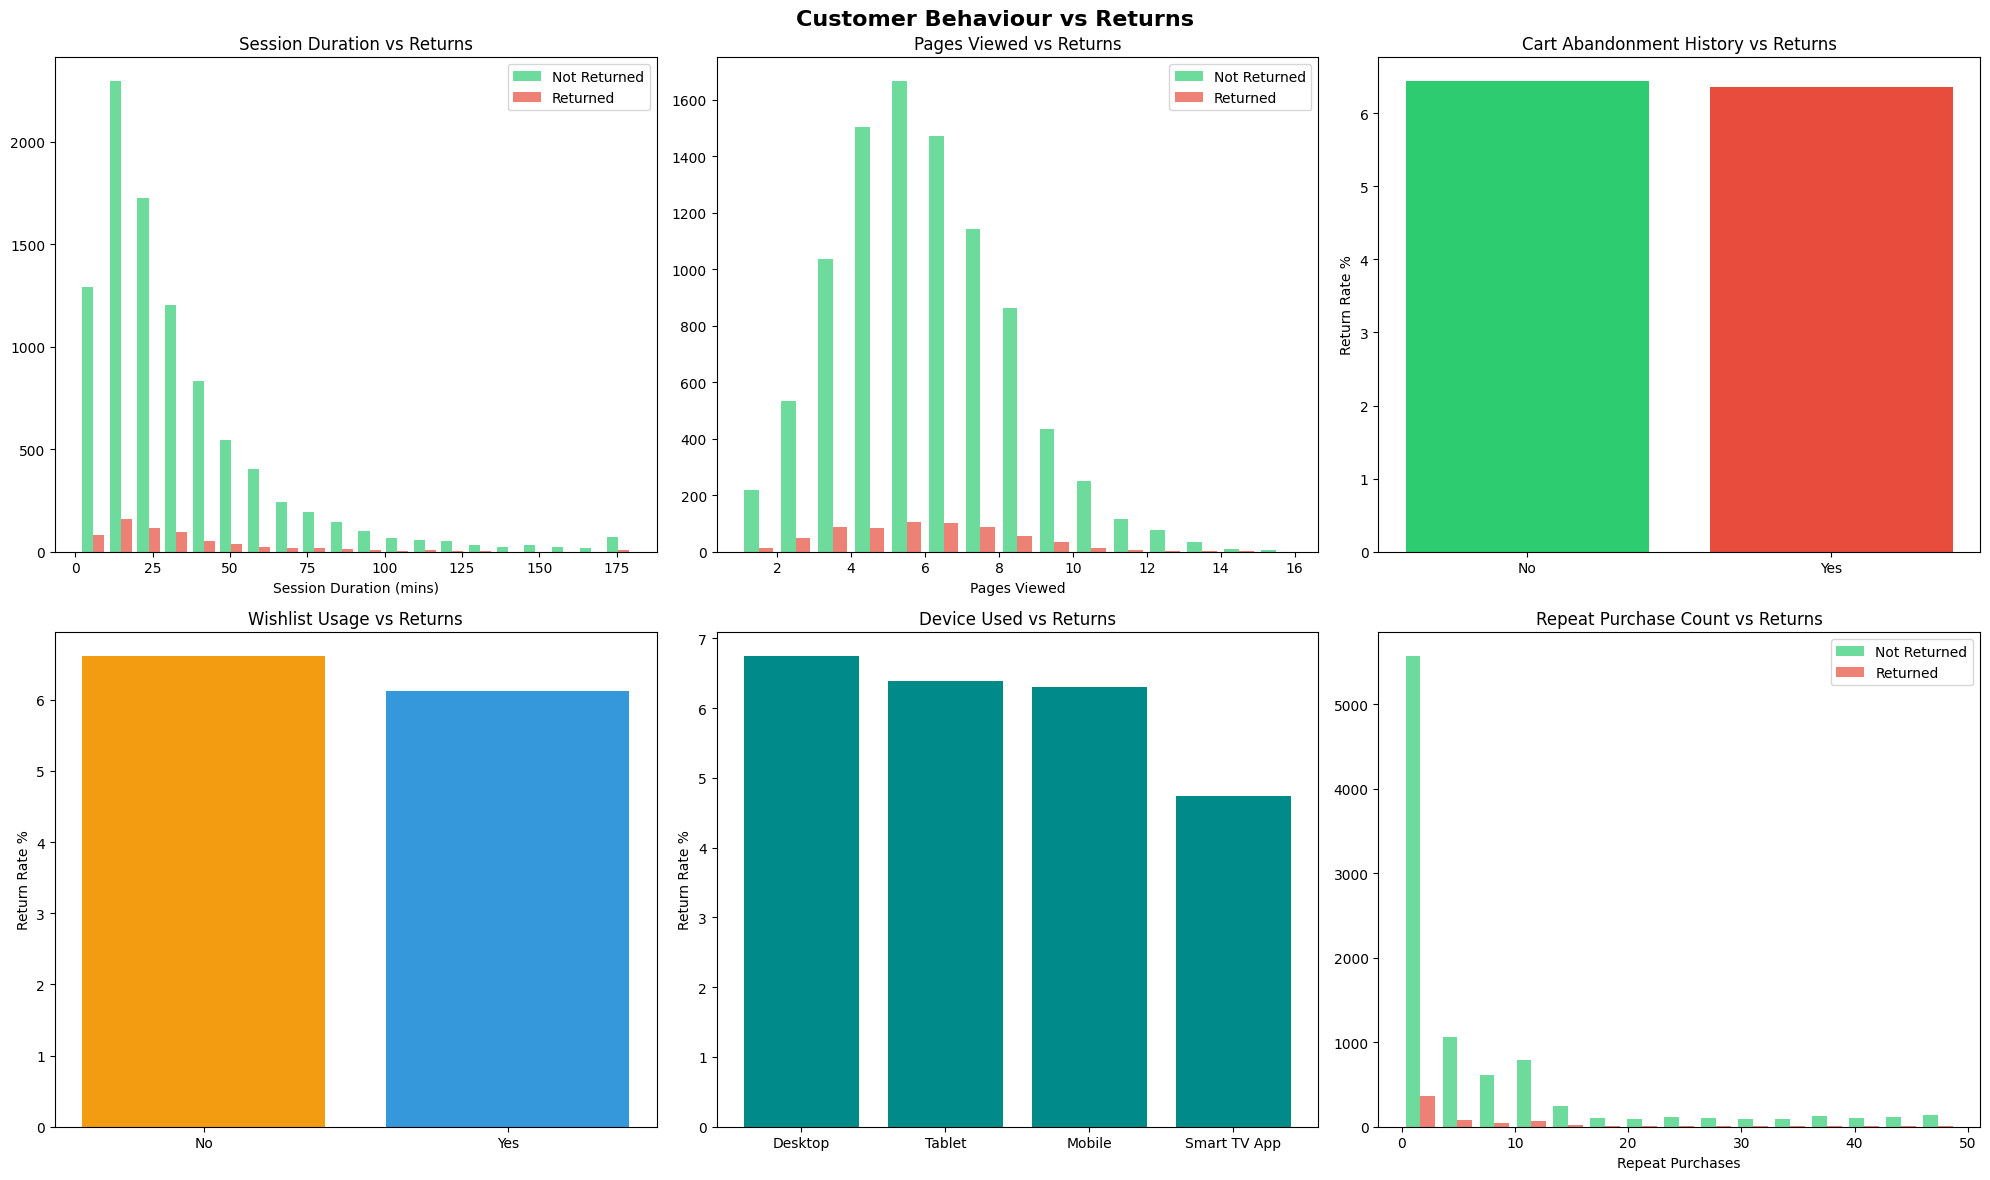

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Customer Behaviour vs Returns", fontsize=16, fontweight="bold")

# 1. Session Duration vs Returns
# Why: Short sessions = impulsive buying = more returns
axes[0,0].hist([df[df["returned"]=="No"]["session_duration_minutes"],
                df[df["returned"]=="Yes"]["session_duration_minutes"]],
               bins=20,
               label=["Not Returned", "Returned"],
               color=["#2ecc71", "#e74c3c"],
               alpha=0.7)
axes[0,0].set_title("Session Duration vs Returns")
axes[0,0].set_xlabel("Session Duration (mins)")
axes[0,0].legend()

# 2. Pages Viewed vs Returns
# Why: More pages = more considered purchase = less returns
axes[0,1].hist([df[df["returned"]=="No"]["pages_viewed"],
                df[df["returned"]=="Yes"]["pages_viewed"]],
               bins=15,
               label=["Not Returned", "Returned"],
               color=["#2ecc71", "#e74c3c"],
               alpha=0.7)
axes[0,1].set_title("Pages Viewed vs Returns")
axes[0,1].set_xlabel("Pages Viewed")
axes[0,1].legend()

# 3. Cart Abandoned Before vs Returns
# Why: Previous cart abandonment signals indecisiveness → higher return risk
cart_returns = df.groupby("cart_abandoned_before")["returned"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
)
axes[0,2].bar(cart_returns.index, cart_returns.values, color=["#2ecc71", "#e74c3c"])
axes[0,2].set_title("Cart Abandonment History vs Returns")
axes[0,2].set_ylabel("Return Rate %")

# 4. Wishlist Used vs Returns
# Why: Wishlist users are more intentional buyers → less returns
wishlist_returns = df.groupby("wishlist_used")["returned"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
)
axes[1,0].bar(wishlist_returns.index, wishlist_returns.values, color=["#f39c12", "#3498db"])
axes[1,0].set_title("Wishlist Usage vs Returns")
axes[1,0].set_ylabel("Return Rate %")

# 5. Device Used vs Returns
# Why: Mobile shoppers may make more impulsive purchases
device_returns = df.groupby("device_used")["returned"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).sort_values(ascending=False)
axes[1,1].bar(device_returns.index, device_returns.values, color="darkcyan")
axes[1,1].set_title("Device Used vs Returns")
axes[1,1].set_ylabel("Return Rate %")

# 6. Repeat Purchase Count vs Returns
# Why: Loyal customers know what they're buying → return less
axes[1,2].hist([df[df["returned"]=="No"]["repeat_purchase_count"],
                df[df["returned"]=="Yes"]["repeat_purchase_count"]],
               bins=15,
               label=["Not Returned", "Returned"],
               color=["#2ecc71", "#e74c3c"],
               alpha=0.7)
axes[1,2].set_title("Repeat Purchase Count vs Returns")
axes[1,2].set_xlabel("Repeat Purchases")
axes[1,2].legend()

plt.tight_layout()
plt.show()

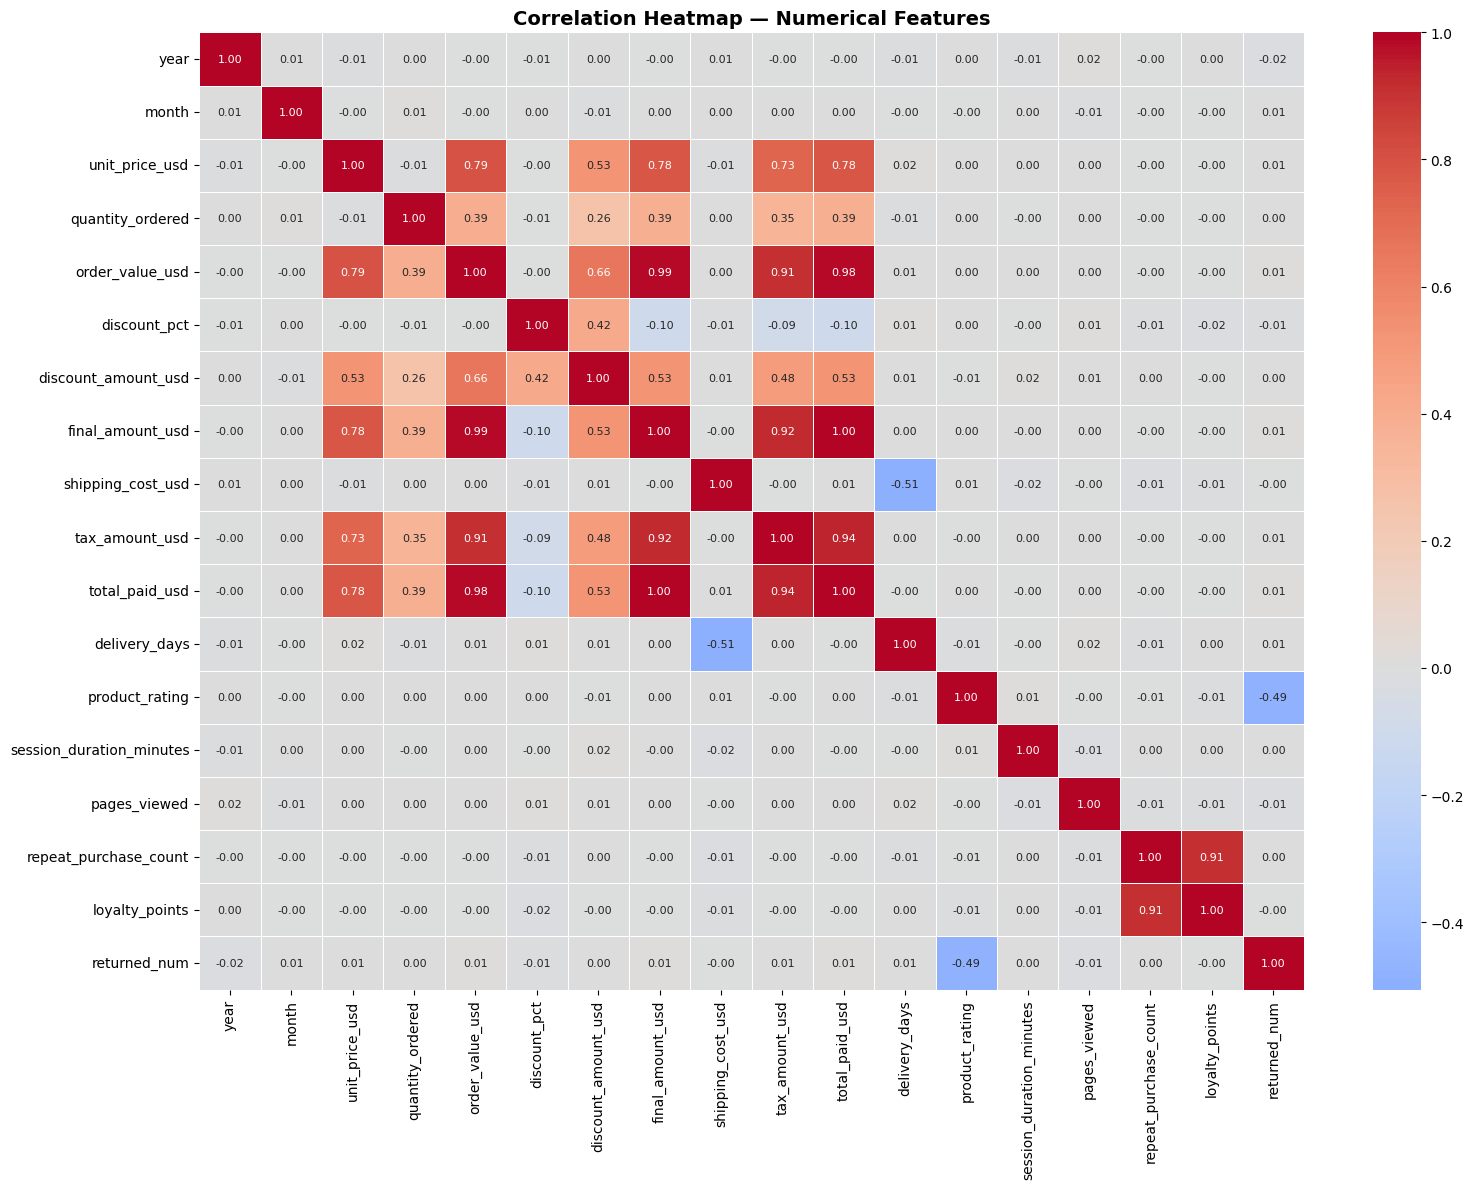


📊 Top features correlated with returns:
final_amount_usd            0.013734
total_paid_usd              0.013189
order_value_usd             0.012391
unit_price_usd              0.010926
delivery_days               0.009978
month                       0.009623
tax_amount_usd              0.008588
repeat_purchase_count       0.002806
quantity_ordered            0.002704
session_duration_minutes    0.002396
discount_amount_usd         0.001590
loyalty_points             -0.001471
shipping_cost_usd          -0.004987
discount_pct               -0.008907
pages_viewed               -0.013348
year                       -0.018210
product_rating             -0.485247
Name: returned_num, dtype: float64


In [19]:
# Convert returned to numeric for correlation
df_corr = df.copy()
df_corr["returned_num"] = (df_corr["returned"] == "Yes").astype(int)

numerical_cols = [
    "year", "month", "unit_price_usd", "quantity_ordered",
    "order_value_usd", "discount_pct", "discount_amount_usd",
    "final_amount_usd", "shipping_cost_usd", "tax_amount_usd",
    "total_paid_usd", "delivery_days", "product_rating",
    "session_duration_minutes", "pages_viewed",
    "repeat_purchase_count", "loyalty_points", "returned_num"
]

plt.figure(figsize=(16, 12))
corr_matrix = df_corr[numerical_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Correlation Heatmap — Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print top features correlated with returns
print("\n📊 Top features correlated with returns:")
print(corr_matrix["returned_num"].sort_values(ascending=False)[1:])